In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('covid19_tweeter_dataset.csv')
df.head()


,Unnamed: 0,Label,Datetime,Tweet,Tokanize_tweet
0,0,-1,2021-01-10 22:06:41+00:00,अमेरिकामा कोभिड बाट एकै दिन चार हजारभन्दा बढीक...,"अमेरिकामा,कोभिड,बाट,एकै,दिन,चार,हजारभन्दा,बढीक..."
1,1,-1,2021-01-10 17:49:34+00:00,कोभिड का कारण विदेशमा रहेका नेपालीहरुमा मानसिक...,"कोभिड,का,कारण,विदेशमा,रहेका,नेपालीहरुमा,मानसिक..."
2,2,1,2021-01-10 16:18:34+00:00,नेपालमा क्लोभर बायोफार्मास्युटिकल्स अस्ट्रेलिय...,"नेपालमा,क्लोभर,बायोफार्मास्युटिकल्स,अस्ट्रेलिय..."
3,3,0,2021-01-10 15:12:17+00:00,कोभिड को खोप पनि लगाइयो,"कोभिड,को,खोप,पनि,लगाइयो"
4,4,-1,2021-01-10 15:07:12+00:00,अमेरिकामा कोभिड को नयाँ रेकर्ड एकै दिन हजारभन्...,"अमेरिकामा,कोभिड,को,नयाँ,रेकर्ड,एकै,दिन,हजारभन्..."


In [6]:
df.tail()

,Unnamed: 0,Label,Datetime,Tweet,Tokanize_tweet
33469,33469,0,2020-02-12 01:33:08+00:00,कोरोना भाइरसलाई विश्व स्वास्थ्य संगठनले दियो न...,"कोरोना,भाइरसलाई,विश्व,स्वास्थ्य,संगठनले,नाम,कोभिड"
33470,33470,0,2020-02-12 00:38:07+00:00,डब्ल्युएचओले दियाेको कोरोनाको नयाँ नाम कोभिड,"डब्ल्युएचओले,दियाेको,कोरोनाको,नाम,कोभिड"
33471,33471,0,2020-02-11 19:37:26+00:00,कोरोना भाइरस संक्रमणको औपचारिक नाम अब कोभिड,"कोरोना,भाइरस,संक्रमणको,औपचारिक,नाम,कोभिड"
33472,33472,0,2020-02-11 16:36:40+00:00,विश्व स्वास्थ्य संगठन डब्लुएचओ ले नोबल कोरोना ...,"विश्व,स्वास्थ्य,संगठन,डब्लुएचओ,नोबल,कोरोना,भाइ..."
33473,33473,0,2020-02-11 15:22:16+00:00,कोरोनाभाइरसका सङ्क्रमणको नाम कोभिड भनेर विश्व ...,"कोरोनाभाइरसका,सङ्क्रमणको,नाम,कोभिड,विश्व,स्वास..."


In [13]:
df.describe(include='all')

,Unnamed: 0,Label,Datetime,Tweet,Tokanize_tweet
count,33474.000000,33474,33474,33474,33471
unique,NaN,33,33382,33458,33391
top,NaN,1,2020-12-13 12:04:45+00:00,यी हुन् अहिलेसम्म कोभिड नभेटिएका देश तथा भूभाग...,कोभिड
freq,NaN,14982,3,2,6
mean,16736.500000,NaN,NaN,NaN,NaN
std,9663.255792,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,8368.250000,NaN,NaN,NaN,NaN
50%,16736.500000,NaN,NaN,NaN,NaN
75%,25104.750000,NaN,NaN,NaN,NaN


In [14]:
df['Label'].value_counts()

Label
1                                                                                                                                                                                                                                                                                                   14982
-1                                                                                                                                                                                                                                                                                                  13593
0                                                                                                                                                                                                                                                                                                    4860
neutral""                                                                                           

In [22]:
count = (df["Label"] == "1").sum()
print("Number of tweets labeled as positive:", count)
count = (df["Label"] == "0").sum()
print("Number of tweets labeled as neutral:", count)
count = (df["Label"] == "-1").sum()
print("Number of tweets labeled as negative:", count)

Number of tweets labeled as positive: 14982
Number of tweets labeled as neutral: 4860
Number of tweets labeled as negative: 13593


In [29]:
df["Label_text"] = df["Label"].map({
    "-1": "Negative",
     "0": "Neutral",
     "1": "Positive"
})

In [30]:
df.head()

,Unnamed: 0,Label,Datetime,Tweet,Tokanize_tweet,Label_text
0,0,-1,2021-01-10 22:06:41+00:00,अमेरिकामा कोभिड बाट एकै दिन चार हजारभन्दा बढीक...,"अमेरिकामा,कोभिड,बाट,एकै,दिन,चार,हजारभन्दा,बढीक...",Negative
1,1,-1,2021-01-10 17:49:34+00:00,कोभिड का कारण विदेशमा रहेका नेपालीहरुमा मानसिक...,"कोभिड,का,कारण,विदेशमा,रहेका,नेपालीहरुमा,मानसिक...",Negative
2,2,1,2021-01-10 16:18:34+00:00,नेपालमा क्लोभर बायोफार्मास्युटिकल्स अस्ट्रेलिय...,"नेपालमा,क्लोभर,बायोफार्मास्युटिकल्स,अस्ट्रेलिय...",Positive
3,3,0,2021-01-10 15:12:17+00:00,कोभिड को खोप पनि लगाइयो,"कोभिड,को,खोप,पनि,लगाइयो",Neutral
4,4,-1,2021-01-10 15:07:12+00:00,अमेरिकामा कोभिड को नयाँ रेकर्ड एकै दिन हजारभन्...,"अमेरिकामा,कोभिड,को,नयाँ,रेकर्ड,एकै,दिन,हजारभन्...",Negative


/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from

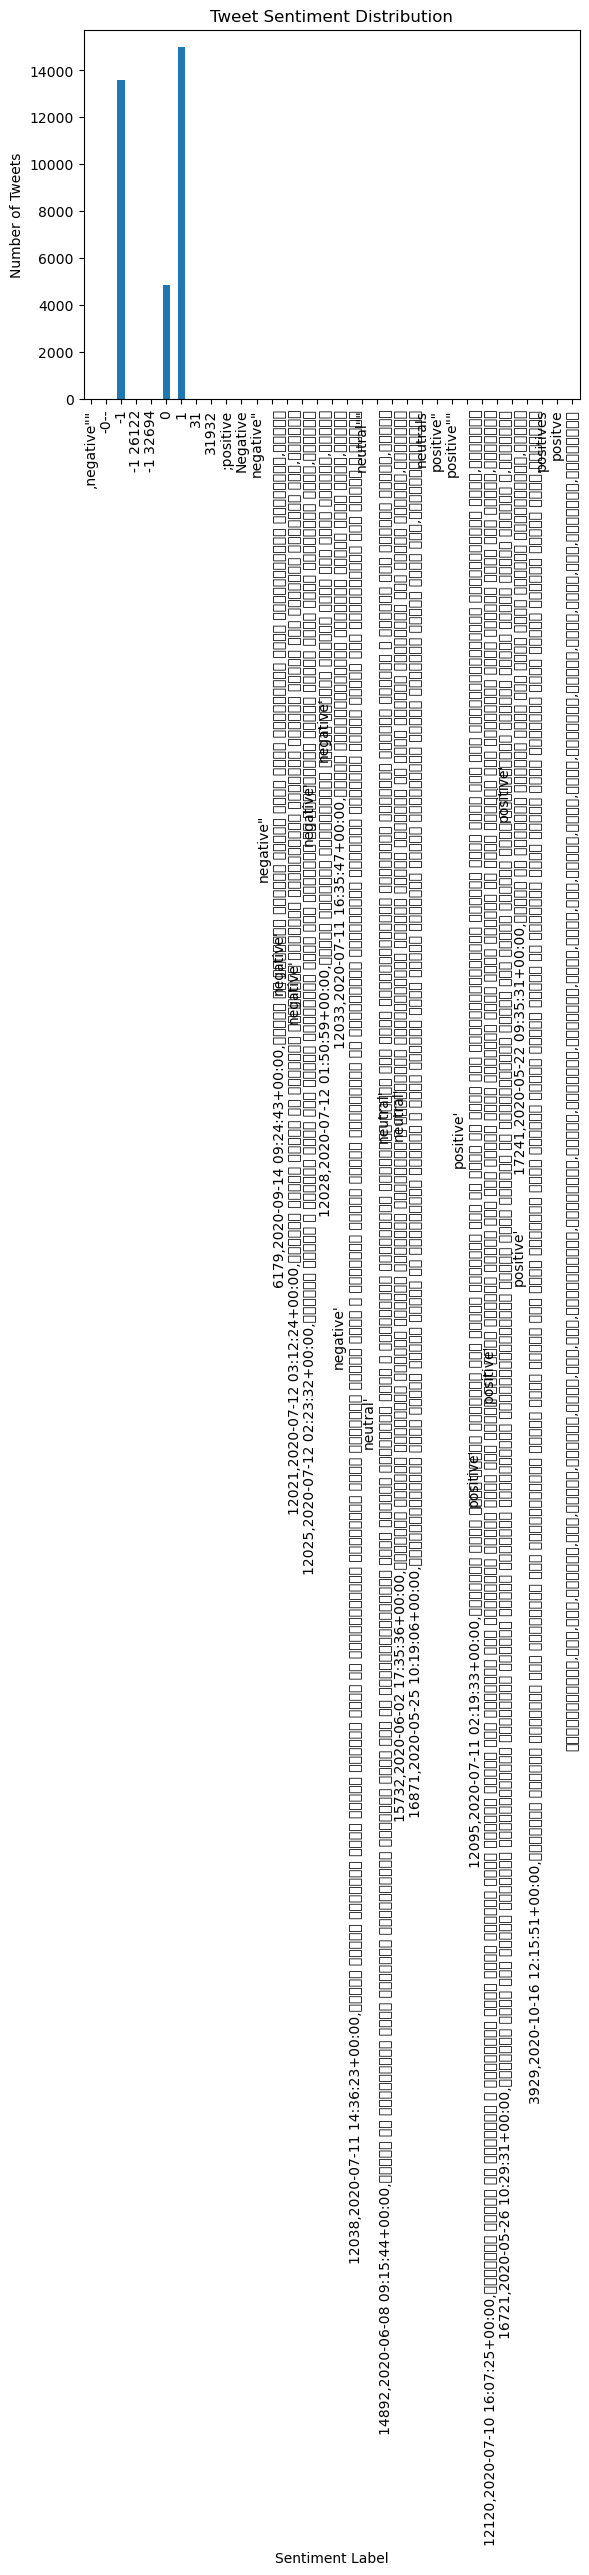

In [23]:
import matplotlib.pyplot as plt

counts = df["Label"].value_counts().sort_index()

counts.plot(kind="bar")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Tweets")
plt.title("Tweet Sentiment Distribution")
plt.show()
